# NB03B — Validación de speckle óptico 2D en $z=2\lambda$

**Proyecto:** simulación de speckle óptico mediante PINN-SIREN y la ecuación de Helmholtz.

**Objetivo:** comprobar que la arquitectura modal validada en NB03 reproduce cinco campos speckle aleatorios hasta una distancia normalizada de $2\lambda$, usando el método del espectro angular como referencia independiente.

Este notebook no modifica NB03 en $1\lambda$. Constituye una extensión controlada y separada.

## 1. Lugar de NB03B dentro de la metodología

La secuencia de validación es:

$$
\mathrm{NB01}\;(1\mathrm{D})
\longrightarrow
\mathrm{NB02}\;(2\mathrm{D\ analítico})
\longrightarrow
\mathrm{NB02B}\;(\mathrm{arquitectura\ modal})
\longrightarrow
\mathrm{NB03}\;(\mathrm{speckle},\;z=1\lambda)
\longrightarrow
\boxed{\mathrm{NB03B}\;(\mathrm{speckle},\;z=2\lambda)}.
$$

NB02B mostró que la arquitectura puede resolver una solución multimodal conocida hasta $2\lambda$. NB03B comprueba ahora el caso aleatorio de interés físico.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

RUN_DIR = PROJECT_ROOT / 'results' / 'nb03_distance_pilot' / 'z2_omega1_five_120s'
RAW_SUMMARY = RUN_DIR / 'summary.json'
VALIDATION_SUMMARY = RUN_DIR / 'validation_summary.json'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TRAIN_SCRIPT = PROJECT_ROOT / 'scripts' / 'experiments' / 'nb03_distance_pilot.py'
SUMMARY_SCRIPT = PROJECT_ROOT / 'scripts' / 'experiments' / 'nb03_z2_omega1_summary.py'

required = [RAW_SUMMARY, VALIDATION_SUMMARY, TRAIN_SCRIPT, SUMMARY_SCRIPT]
missing = [path for path in required if not path.exists()]
if missing:
    raise FileNotFoundError('Faltan archivos requeridos:\n' + '\n'.join(map(str, missing)))

raw = json.loads(RAW_SUMMARY.read_text(encoding='utf-8'))
report = json.loads(VALIDATION_SUMMARY.read_text(encoding='utf-8'))
print('Estructura del proyecto localizada correctamente.')
print(f'Corrida validada: {RUN_DIR.relative_to(PROJECT_ROOT)}')

Estructura del proyecto localizada correctamente.
Corrida validada: results\nb03_distance_pilot\z2_omega1_five_120s


## 2. Problema físico

En coordenadas cartesianas normalizadas $(\tilde x,\tilde z)$, el campo complejo satisface

$$
\frac{\partial^2 E}{\partial \tilde x^2}
+\frac{\partial^2 E}{\partial \tilde z^2}
+\tilde k^2 E=0,
\qquad \tilde k=2\pi.
$$

La coordenada $\tilde x=x/\lambda$ es transversal y $\tilde z=z/\lambda$ es la dirección de propagación. El dominio de este experimento es

$$
-10\leq \tilde x<10,
\qquad 0\leq \tilde z\leq2.
$$

Por tanto, sigue siendo un problema 2D cartesiano $(x,z)$; la expansión modal no cambia el sistema de coordenadas.

## 3. Representación modal y condición de Cauchy dura

El campo se escribe como una suma de ondas planas transversales:

$$
E(\tilde x,\tilde z)=\sum_m a_m(\tilde z)e^{i\tilde k_{x,m}\tilde x}.
$$

Cada coeficiente satisface la ecuación modal derivada de Helmholtz:

$$
a_m''(\tilde z)+\tilde k_{z,m}^{,2}a_m(\tilde z)=0,
\qquad
\tilde k_{z,m}^{,2}=\tilde k^2-\tilde k_{x,m}^{,2}.
$$

La PINN impone exactamente el campo y su derivada inicial mediante

$$
a_{m,\theta}(\tilde z)
=a_m(0)+\tilde z\,a_m'(0)+\tilde z^2N_{m,\theta}(\tilde z).
$$

Por construcción, $a_{m,\theta}(0)=a_m(0)$ y $a'_{m,\theta}(0)=a'_m(0)$. No se necesita una penalización de frontera.

## 4. Arquitectura congelada

NB03B mantiene la configuración oficial de NB03:

| Elemento | Valor |
|---|---:|
| Entrada | $\tilde z$ |
| Capas ocultas | 4 |
| Neuronas por capa | 128 |
| Frecuencia primera capa | $\omega_0=1$ |
| Frecuencia interna | 1 |
| Modos complejos propagantes | 41 |
| Salidas reales | 82 |
| Condición inicial | Cauchy dura |
| Etiquetas interiores | Ninguna |

Los checkpoints de $z=1\lambda$ se usan como inicialización. Después se redefine el intervalo de la red a $0\leq\tilde z\leq2$ y se refina únicamente con el residuo físico.

In [2]:
config = raw['configuration']
assert config['source_variant'] == 'omega1'
assert np.isclose(config['first_omega'], 1.0)
assert np.isclose(config['hidden_omega'], 1.0)
assert np.allclose(config['distances'], [2.0])
assert config['seeds'] == [42, 123, 321, 777, 2026]
assert report['architecture']['first_omega'] == 1.0
assert report['protocol']['training_labels'] is False
assert report['protocol']['selection_uses_reference_field'] is False

pd.Series({
    'distancia máxima (lambda)': 2,
    'pantallas aleatorias': len(config['seeds']),
    'segundos de refinamiento por pantalla': config['seconds'],
    'puntos de colocación': config['n_train'],
    'omega primera capa': config['first_omega'],
    'omega interna': config['hidden_omega'],
    'dispositivo registrado': raw['runtime']['device'],
}, name='valor').to_frame()

,valor
distancia máxima (lambda),2
pantallas aleatorias,5
segundos de refinamiento por pantalla,120.0
puntos de colocación,1024
omega primera capa,1.0
omega interna,1.0
dispositivo registrado,cuda


## 5. Independencia de la referencia

Durante el refinamiento se minimiza exclusivamente el residuo modal de Helmholtz. Los 997 puntos utilizados para seleccionar el mejor estado también evalúan únicamente el residuo.

El espectro angular no proporciona etiquetas durante el entrenamiento. Se utiliza después para medir el campo complejo en 201 planos entre $0$ y $2\lambda$.

## 6. Criterios de aceptación

Cada pantalla debe satisfacer simultáneamente:

| Métrica | Criterio |
|---|---:|
| Error $L^2$ complejo completo en $2\lambda$ | $<5\%$ |
| Coherencia compleja | $>0.99$ |
| Correlación de intensidad | $>0.99$ |
| Diferencia de contraste | $<0.05$ |
| Máximo $L^2$ propagante en los 201 planos | $<5\%$ |
| Errores de Cauchy | $<10^{-6}$ |

El residuo normalizado de Helmholtz se reporta como diagnóstico físico independiente.

In [3]:
rows = []
for item in report['per_screen']:
    rows.append({
        'pantalla': item['screen_seed'],
        'L2 completo final (%)': 100 * item['l2_full_final'],
        'L2 propagante final (%)': 100 * item['l2_propagating_final'],
        'máximo propagante (%)': 100 * item['l2_propagating_max'],
        'coherencia': item['coherence_full_final'],
        'correlación I': item['intensity_correlation_full_final'],
        'C referencia': item['contrast_reference'],
        'C PINN': item['contrast_pinn'],
        '|ΔC|': item['contrast_difference'],
        'residuo': item['residual_normalized_rmse'],
        'aceptada': item['accepted'],
    })

metrics_table = pd.DataFrame(rows).set_index('pantalla')
metrics_table.round({
    'L2 completo final (%)': 4,
    'L2 propagante final (%)': 4,
    'máximo propagante (%)': 4,
    'coherencia': 6,
    'correlación I': 6,
    'C referencia': 4,
    'C PINN': 4,
    '|ΔC|': 6,
    'residuo': 6,
})

,L2 completo final (%),L2 propagante final (%),máximo propagante (%),coherencia,correlación I,C referencia,C PINN,|ΔC|,residuo,aceptada
pantalla,,,,,,,,,,
42,1.0377,0.9321,1.1648,0.999951,0.999944,1.1595,1.1621,0.002666,0.005417,True
123,0.9409,0.8944,1.0810,0.999961,0.999944,1.0684,1.0689,0.000582,0.005385,True
321,1.0057,0.8931,1.0780,0.999951,0.999921,0.9391,0.9377,0.001406,0.004924,True
777,0.8637,0.7940,0.9986,0.999965,0.999929,1.0116,1.0123,0.000720,0.004501,True
2026,1.1175,1.0542,1.0542,0.999960,0.999896,0.8374,0.8369,0.000446,0.004867,True


In [4]:
aggregate = report['aggregate']
print('RESULTADO AGREGADO — NB03B EN z=2 lambda')
print('-' * 64)
print(f"L2 completo medio          : {100*aggregate['l2_full_final']['mean']:.4f}%")
print(f"Peor L2 completo           : {100*aggregate['l2_full_final']['maximum']:.4f}%")
print(f"L2 propagante medio        : {100*aggregate['l2_propagating_final']['mean']:.4f}%")
print(f"Peor máximo sobre z        : {100*aggregate['l2_propagating_max']['maximum']:.4f}%")
print(f"Coherencia media           : {aggregate['coherence_full_final']['mean']:.6f}")
print(f"Correlación de I media     : {aggregate['intensity_correlation_full_final']['mean']:.6f}")
print(f"Error de contraste medio   : {aggregate['contrast_difference']['mean']:.6f}")
print(f"Residuo normalizado medio  : {aggregate['residual_normalized_rmse']['mean']:.6f}")
print(f"Pantallas aceptadas        : {aggregate['accepted_screens']}/{aggregate['total_screens']}")
assert report['all_screens_accepted']

RESULTADO AGREGADO — NB03B EN z=2 lambda
----------------------------------------------------------------
L2 completo medio          : 0.9931%
Peor L2 completo           : 1.1175%
L2 propagante medio        : 0.9136%
Peor máximo sobre z        : 1.1648%
Coherencia media           : 0.999958
Correlación de I media     : 0.999927
Error de contraste medio   : 0.001164
Residuo normalizado medio  : 0.005019
Pantallas aceptadas        : 5/5


## 7. Error a lo largo de la propagación

No basta con observar únicamente el plano final. Las siguientes curvas muestran el error propagante en los 201 planos usados para la evaluación independiente.

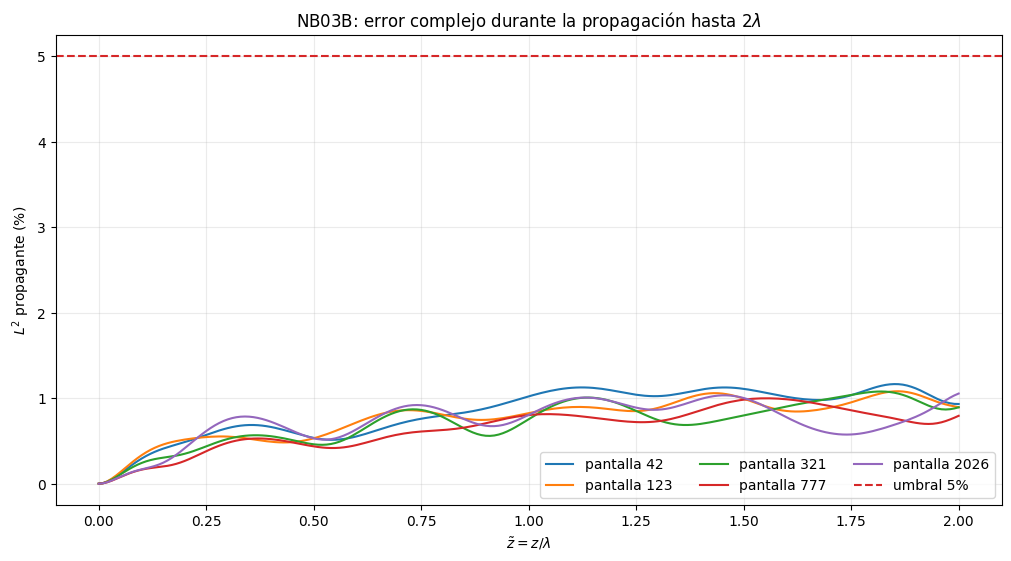

Figura guardada: results\figures\nb03b_z2_l2_multiscreen.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)
for seed in config['seeds']:
    data = np.load(RUN_DIR / f'seed{seed}_z2.npz')
    ax.plot(data['z_lambda'], 100 * data['l2_propagating'], label=f'pantalla {seed}')
ax.axhline(5, color='tab:red', linestyle='--', label='umbral 5%')
ax.set(xlabel=r'$\tilde z=z/\lambda$', ylabel=r'$L^2$ propagante (%)',
       title=r'NB03B: error complejo durante la propagación hasta $2\lambda$')
ax.grid(alpha=0.25)
ax.legend(ncol=3)
path_l2 = FIGURES_DIR / 'nb03b_z2_l2_multiscreen.png'
fig.savefig(path_l2, dpi=180, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {path_l2.relative_to(PROJECT_ROOT)}')

## 8. Visualización del campo 2D $(x,z)$

La intensidad es

$$I(\tilde x,\tilde z)=|E(\tilde x,\tilde z)|^2.$$

Estas imágenes muestran la evolución longitudinal de una realización. El eje horizontal es la coordenada transversal y el eje vertical es la distancia de propagación. No es una gráfica 3D ni una imagen transversal $(x,y)$ de cámara.

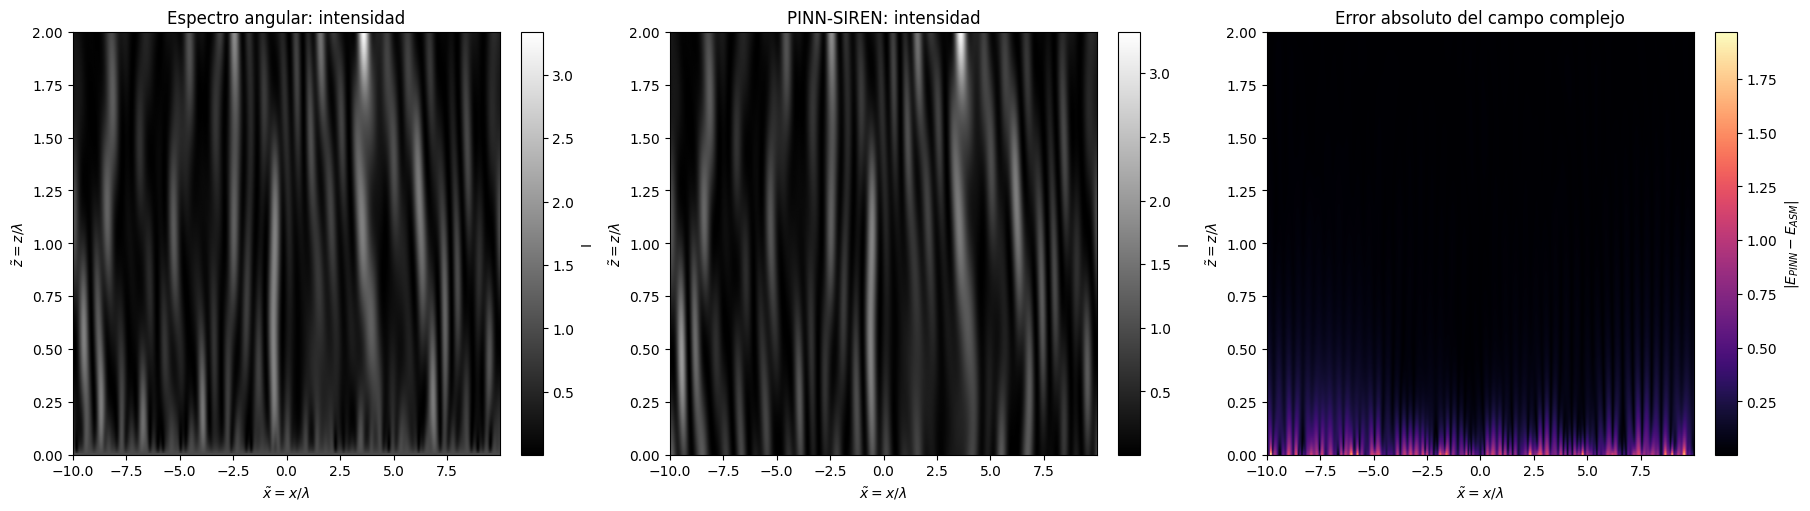

Figura guardada: results\figures\nb03b_z2_propagation_screen42.png


In [6]:
example_seed = 42
example = dict(np.load(RUN_DIR / f'seed{example_seed}_z2.npz'))
z = example['z_lambda']
field_pinn = example['field_pred']
field_ref = example['field_full']
x = np.linspace(-10, 10, field_ref.shape[1], endpoint=False)
I_ref = np.abs(field_ref) ** 2
I_pinn = np.abs(field_pinn) ** 2
absolute_error = np.abs(field_pinn - field_ref)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
extent = [x.min(), x.max(), z.min(), z.max()]
im0 = axes[0].imshow(I_ref, origin='lower', aspect='auto', extent=extent, cmap='gray')
axes[0].set_title('Espectro angular: intensidad')
fig.colorbar(im0, ax=axes[0], label='I')
im1 = axes[1].imshow(I_pinn, origin='lower', aspect='auto', extent=extent, cmap='gray')
axes[1].set_title('PINN-SIREN: intensidad')
fig.colorbar(im1, ax=axes[1], label='I')
im2 = axes[2].imshow(absolute_error, origin='lower', aspect='auto', extent=extent, cmap='magma')
axes[2].set_title('Error absoluto del campo complejo')
fig.colorbar(im2, ax=axes[2], label=r'$|E_{PINN}-E_{ASM}|$')
for ax in axes:
    ax.set_xlabel(r'$\tilde x=x/\lambda$')
    ax.set_ylabel(r'$\tilde z=z/\lambda$')
path_map = FIGURES_DIR / 'nb03b_z2_propagation_screen42.png'
fig.savefig(path_map, dpi=180, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {path_map.relative_to(PROJECT_ROOT)}')

La franja de error próxima a $\tilde z=0$ no representa una violación de la condición de Cauchy. La PINN modal propaga la proyección de 41 modos propagantes, mientras que el campo completo del espectro angular conserva inicialmente componentes evanescentes. Estas componentes decaen rápidamente con $z$; por ello se reportan por separado el error frente al campo completo y el error dentro del subespacio propagante.

## 9. Comparación en el plano final $z=2\lambda$

Se comparan intensidad, partes real e imaginaria, error complejo y distribución de intensidad normalizada.

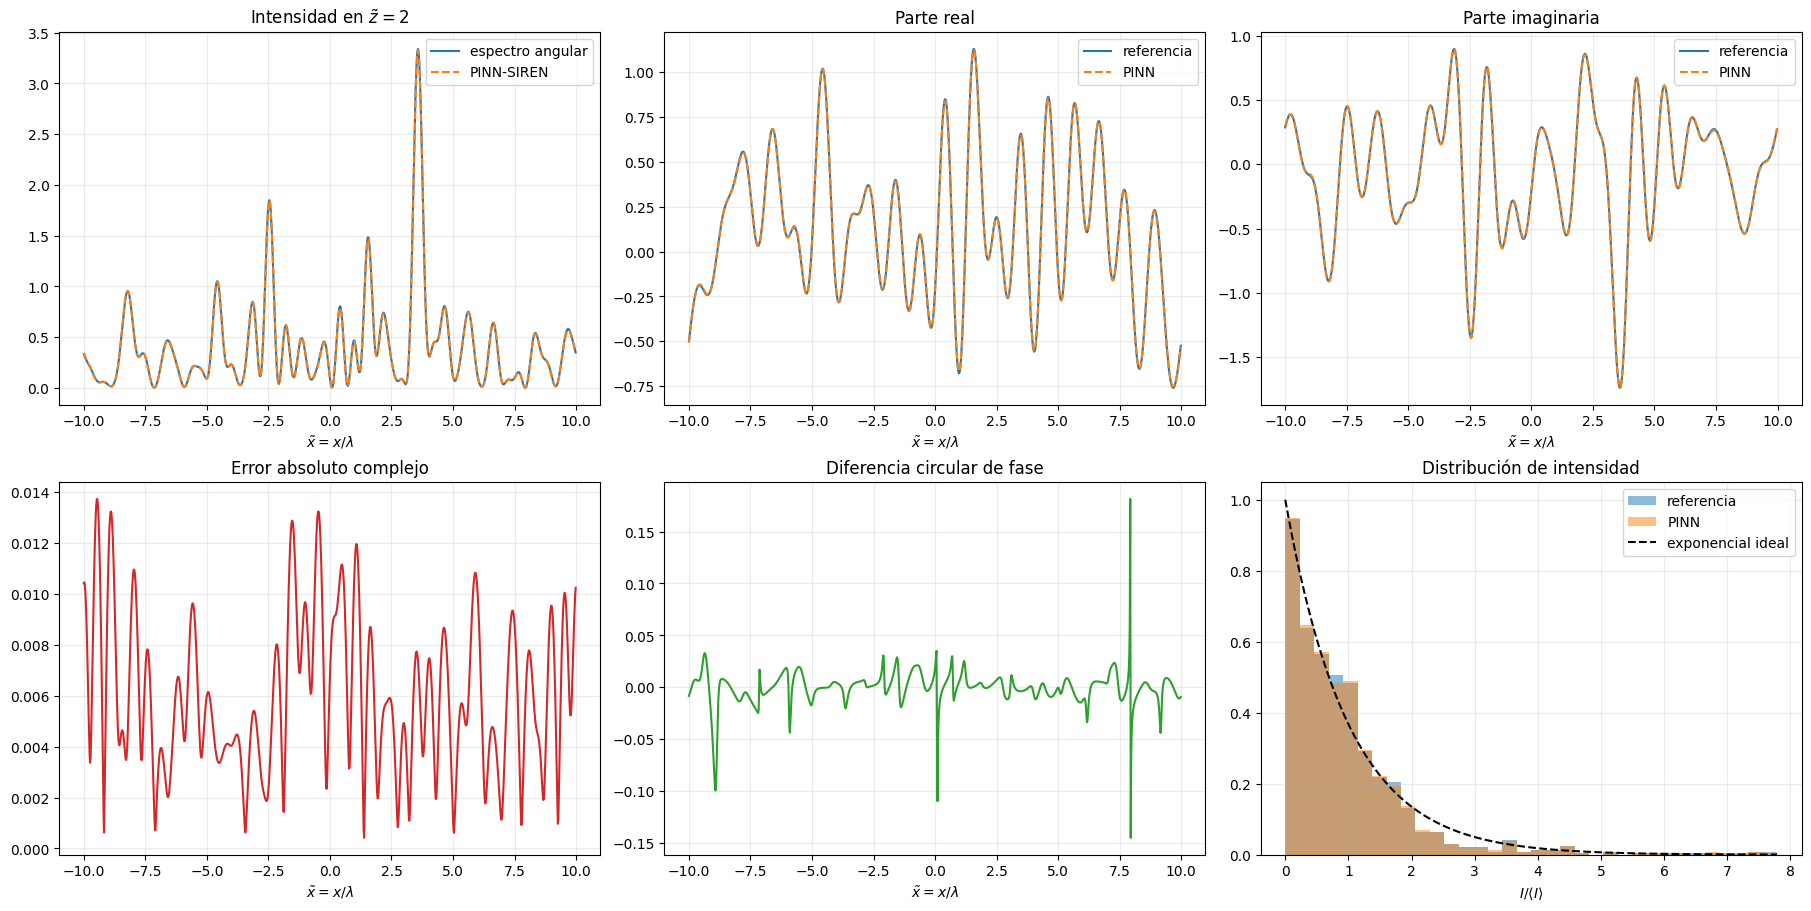

Figura guardada: results\figures\nb03b_z2_final_plane_screen42.png


In [7]:
ref_final = field_ref[-1]
pinn_final = field_pinn[-1]
I_ref_final = np.abs(ref_final) ** 2
I_pinn_final = np.abs(pinn_final) ** 2
phase_error = np.angle(pinn_final * np.conj(ref_final))

fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
axes[0,0].plot(x, I_ref_final, label='espectro angular')
axes[0,0].plot(x, I_pinn_final, '--', label='PINN-SIREN')
axes[0,0].set_title(r'Intensidad en $\tilde z=2$')
axes[0,0].legend()
axes[0,1].plot(x, ref_final.real, label='referencia')
axes[0,1].plot(x, pinn_final.real, '--', label='PINN')
axes[0,1].set_title('Parte real')
axes[0,1].legend()
axes[0,2].plot(x, ref_final.imag, label='referencia')
axes[0,2].plot(x, pinn_final.imag, '--', label='PINN')
axes[0,2].set_title('Parte imaginaria')
axes[0,2].legend()
axes[1,0].plot(x, np.abs(pinn_final-ref_final), color='tab:red')
axes[1,0].set_title('Error absoluto complejo')
axes[1,1].plot(x, phase_error, color='tab:green')
axes[1,1].set_title('Diferencia circular de fase')

nr = I_ref_final / I_ref_final.mean()
npred = I_pinn_final / I_pinn_final.mean()
bins = np.linspace(0, np.percentile(np.r_[nr, npred], 99.5), 35)
axes[1,2].hist(nr, bins=bins, density=True, alpha=.5, label='referencia')
axes[1,2].hist(npred, bins=bins, density=True, alpha=.5, label='PINN')
eta = np.linspace(0, bins[-1], 300)
axes[1,2].plot(eta, np.exp(-eta), 'k--', label='exponencial ideal')
axes[1,2].set_title('Distribución de intensidad')
axes[1,2].legend()
for ax in axes.ravel()[:5]:
    ax.set_xlabel(r'$\tilde x=x/\lambda$')
    ax.grid(alpha=.25)
axes[1,2].set_xlabel(r'$I/\langle I\rangle$')
axes[1,2].grid(alpha=.25)
path_final = FIGURES_DIR / 'nb03b_z2_final_plane_screen42.png'
fig.savefig(path_final, dpi=180, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {path_final.relative_to(PROJECT_ROOT)}')

## 10. Comprobaciones de integridad

Se verifica que los cinco archivos numéricos existan, sean finitos y contengan exactamente 201 planos desde $0$ hasta $2\lambda$.

In [8]:
checks = []
for seed in config['seeds']:
    path = RUN_DIR / f'seed{seed}_z2.npz'
    data = np.load(path)
    finite = all(np.isfinite(data[key]).all() for key in data.files)
    checks.append({
        'pantalla': seed,
        'archivo': path.name,
        'planos': len(data['z_lambda']),
        'z inicial': float(data['z_lambda'][0]),
        'z final': float(data['z_lambda'][-1]),
        'valores finitos': finite,
    })
    assert finite and len(data['z_lambda']) == 201
    assert np.isclose(data['z_lambda'][0], 0) and np.isclose(data['z_lambda'][-1], 2)
pd.DataFrame(checks).set_index('pantalla')

,archivo,planos,z inicial,z final,valores finitos
pantalla,,,,,
42,seed42_z2.npz,201,0.0,2.0,True
123,seed123_z2.npz,201,0.0,2.0,True
321,seed321_z2.npz,201,0.0,2.0,True
777,seed777_z2.npz,201,0.0,2.0,True
2026,seed2026_z2.npz,201,0.0,2.0,True


## 11. Reproducción protegida

La siguiente celda está desactivada para evitar sobrescribir o duplicar una corrida costosa. Para repetir el protocolo debe elegirse un nombre de salida nuevo.

In [9]:
RUN_TRAINING = False

if RUN_TRAINING:
    command = [
        sys.executable, '-u', str(TRAIN_SCRIPT),
        '--seeds', '42', '123', '321', '777', '2026',
        '--distances', '2',
        '--seconds', '120',
        '--n-train', '1024',
        '--threads', '4',
        '--name', 'z2_omega1_five_120s_replica',
        '--first-omega', '1',
        '--hidden-omega', '1',
        '--source-variant', 'omega1',
        '--device', 'cuda',
    ]
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)
else:
    print('Entrenamiento desactivado. Se cargan los resultados validados existentes.')

Entrenamiento desactivado. Se cargan los resultados validados existentes.


## 12. Qué demuestra y qué no demuestra

| Sí demuestra | Todavía no demuestra |
|---|---|
| Propagación de cinco campos speckle aleatorios hasta $2\lambda$ | Funcionamiento para cualquier distancia |
| Cumplimiento de Helmholtz mediante el residuo modal | Generalización a pantallas no vistas sin reentrenar |
| Condición de Cauchy satisfecha exactamente | Imagen transversal de cámara $I(x,y)$ |
| Concordancia con el espectro angular en 201 planos | Aceleración frente a FEM |
| Robustez frente a cinco pantallas físicas | Validación experimental de laboratorio |

Los contrastes individuales no tienen que satisfacer $|C-1|<0.1$: ese límite corresponde a una estadística de conjunto. Para cada realización se exige que la PINN reproduzca el contraste de su referencia, es decir, $|C_{\mathrm{PINN}}-C_{\mathrm{ref}}|<0.05$.

## Conclusión

Con la arquitectura PINN-SIREN modal, $\omega_0=1$, condición de Cauchy dura y sin etiquetas interiores, las cinco pantallas aleatorias alcanzaron el plano $z=2\lambda$ con error $L^2$ complejo inferior a 5%. El error completo medio fue aproximadamente **0.993%**, la coherencia media **0.999958** y el peor error propagante observado en los 201 planos fue aproximadamente **1.165%**.

Por tanto, la metodología de NB03 queda validada para las condiciones estudiadas en $z=1\lambda$ y $z=2\lambda$. Esto no autoriza todavía una afirmación de distancia arbitraria.